In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

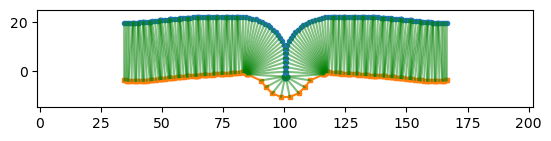

In [1028]:
n_cells = 201
n_vertices = n_cells + 1
data = np.fromfile("output.bin", dtype=np.float64).reshape((-1,2, n_vertices, 2))
time_index = -10  # Last time step
fig, ax = plt.subplots()
apical_plt = plt.plot(data[0,0,:,0], data[0,0,:,1], label='Apical', marker='o', markersize=3)
basal_plt = plt.plot(data[0,1,:,0], data[0,1,:,1], label='Basal', marker='s', markersize=3)
lateral_plts = []
for i in range(n_cells+1):
    lateral_plts.append(plt.plot([data[0,0,i,0], data[0,1,i,0]], [data[0,0,i,1], data[0,1,i,1]], color='green', alpha=0.5))
ax.set_xlim(-1, n_cells+1)
#ax.set_xlim(n_cells/2-0.1*n_cells, n_cells/2+0.1*n_cells)
ax.set_ylim(-15, 25)
ax.set_aspect('equal', adjustable='box')
display_handle = display(fig, display_id=True)
for time in range(data.shape[0]):
    apical_plt[0].set_data(data[time,0,:,0], data[time,0,:,1])
    basal_plt[0].set_data(data[time,1,:,0], data[time,1,:,1])
    for i in range(n_cells+1):
        lateral_plts[i][0].set_data([data[time,0,i,0], data[time,1,i,0]], [data[time,0,i,1], data[time,1,i,1]])
    display_handle.update(fig)
plt.close()

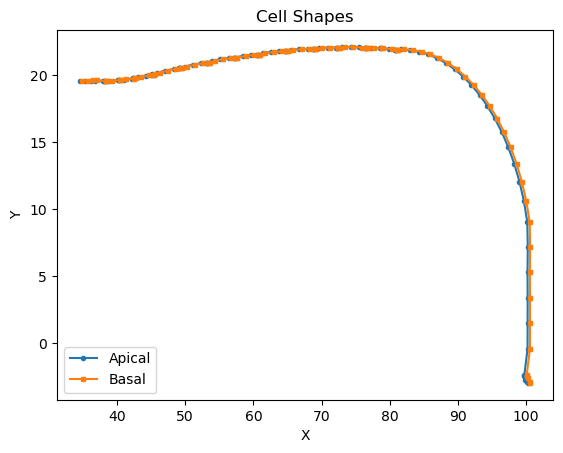

In [1029]:
plt.plot(data[-1,0,:n_vertices//2,0], data[-1,0,:n_vertices//2,1], label='Apical', marker='o', markersize=3)
plt.plot(2*data[-1,0,n_vertices//2,0] - data[-1,0,n_vertices//2:,0], data[-1,0,n_vertices//2:,1], label='Basal', marker='s', markersize=3)
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Cell Shapes')
plt.show()

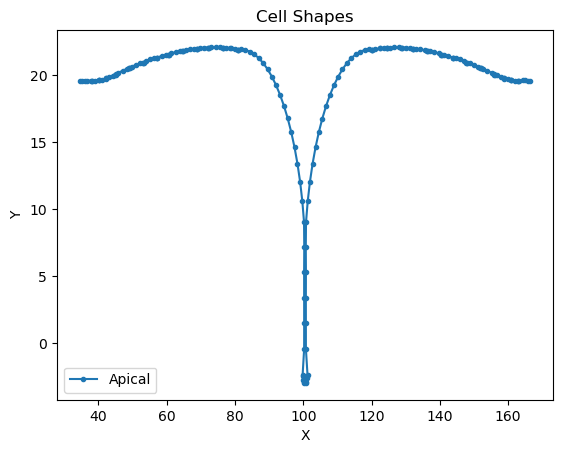

In [1030]:
plt.plot(data[-1,0,:,0], data[-1,0,:,1], label='Apical', marker='o', markersize=3)
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Cell Shapes')
plt.show()